# MF 772 Problem HW3

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from scipy.optimize import brentq
from numpy.polynomial.hermite_e import hermegauss

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Inputs

In [3]:
# ============ REPLACE WITH YOUR DATA ============
NAMES = ["Name A (tight IG)", "Name B (IG)", "Name C (BBB)", "Name D (BB)", "Name E (HY)"]
MATS = np.array([1.0, 3.0, 5.0])            # 3 common maturities (years)
SPREADS_BP = np.array([                     # rows = names, cols = MATS  (PLACEHOLDERS)
    [ 15,  30,  45],
    [ 30,  55,  80],
    [ 60, 100, 140],
    [150, 230, 300],
    [400, 480, 550],
], dtype=float)
RECOV = np.array([0.40, 0.40, 0.40, 0.40, 0.25])   # IG 40%, HY 25% (Lecture 4, slide 37)
# ================================================

R_INDEX  = 0.40          # index recovery given in the problem
RATE     = 0.04          # flat continuously-compounded discount rate (or plug in a SOFR curve)
FREQ     = 4             # quarterly payments
NOTIONAL = 10_000_000    # notional used to report DV01 / JTD in dollars

TRANCHES = [(0, 5), (5, 15), (15, 30), (30, 100)]
BASE_CORR_30 = {5: 0.30, 15: 0.30, 30: 0.30, 100: 0.30}   # keyed by detachment point

N_NAMES   = len(NAMES)
LOSS_UNIT = 100 * (1 - R_INDEX) / N_NAMES     # index loss per default, in index points (= 12)
MAX_LOSS  = LOSS_UNIT * N_NAMES               # = 60 -> K2^- for the super senior

dt     = 1.0 / FREQ
T_GRID = np.round(np.arange(0, MATS.max() + 1e-9, dt), 10)   # t_0 = 0, t_1, ..., t_n
DF     = np.exp(-RATE * T_GRID)
DELTA  = np.full(len(T_GRID), dt * 365 / 360)                 # Act/360 accrual
DELTA[0] = 0.0

def n_of(T):
    """Index of maturity T on the grid."""
    return int(round(T * FREQ))

## (a) CDS survival curves

Piecewise-constant hazard rates, bootstrapped one maturity at a time. Each CDS is priced at par (Lecture 5, eq. 1–2):

$$\frac{S}{2}\sum_n \Delta_n DF(t_n)\big(P(t_{n-1})+P(t_n)\big) = (1-R)\sum_n DF(t_n)\big(P(t_{n-1})-P(t_n)\big)$$

In [4]:
def survival(hazards, t=T_GRID):
    """P(t) = exp(-integral of the piecewise-constant hazard); the last hazard is extended flat."""
    knots = np.concatenate([[0.0], MATS[:len(hazards)]])
    H = np.zeros_like(t, dtype=float)
    for k, h in enumerate(hazards):
        a = knots[k]
        b = knots[k + 1] if k < len(hazards) - 1 else np.inf
        H += h * np.clip(t - a, 0, b - a)
    return np.exp(-H)

def cds_pv_short_protection(S, R, P, T):
    n = n_of(T)
    i = np.arange(1, n + 1)
    prem = S * np.sum(DELTA[i] * DF[i] * (P[i - 1] + P[i]) / 2)
    prot = (1 - R) * np.sum(DF[i] * (P[i - 1] - P[i]))
    return prem - prot

def bootstrap(spreads_bp, R):
    hazards = []
    for T, s in zip(MATS, spreads_bp):
        f = lambda h: cds_pv_short_protection(s / 1e4, R, survival(hazards + [h]), T)
        hazards.append(brentq(f, 1e-10, 10.0))
    return np.array(hazards)

def build_model(spreads_bp):
    """Everything needed downstream from a matrix of CDS spreads."""
    haz  = np.array([bootstrap(spreads_bp[j], RECOV[j]) for j in range(N_NAMES)])
    P    = np.array([survival(list(haz[j])) for j in range(N_NAMES)])  # survival curves  (N x n_t)
    EL   = (1 - RECOV)[:, None] * (1 - P)                             # (b) expected loss curves
    EL_I = EL.mean(axis=0)                                            # (c) index expected loss
    Q_I  = 1 - EL_I / (1 - R_INDEX)                                   # index "survival" / remaining notional
    pdef = EL / (1 - R_INDEX)                                         # Bernoulli p_j(t) with common loss (Lecture 4, slide 44)
    if pdef.max() > 1:
        print("WARNING: some p_j(t) > 1 -- a name is too wide for a common 40% recovery")
    return dict(haz=haz, P=P, EL=EL, EL_I=EL_I, Q_I=Q_I, pdef=pdef)

base = build_model(SPREADS_BP)

hz = pd.DataFrame(base["haz"], index=NAMES,
                  columns=[f"λ {a:g}-{b:g}y" for a, b in zip(np.r_[0, MATS[:-1]], MATS)])
surv = pd.DataFrame(base["P"][:, [n_of(T) for T in MATS]], index=NAMES,
                    columns=[f"P({T:g}y)" for T in MATS])
display(pd.concat([hz, surv], axis=1))

# sanity check: every CDS reprices to par
print("max |repricing error|:",
      max(abs(cds_pv_short_protection(SPREADS_BP[j, k] / 1e4, RECOV[j], base["P"][j], T))
          for j in range(N_NAMES) for k, T in enumerate(MATS)))

,λ 0-1y,λ 1-3y,λ 3-5y,P(1y),P(3y),P(5y)
Name A (tight IG),0.0025,0.0064,0.0119,0.9975,0.9847,0.9616
Name B (IG),0.0051,0.0116,0.0208,0.9949,0.9722,0.9326
Name C (BBB),0.0101,0.0206,0.0356,0.9899,0.9500,0.8847
Name D (BB),0.0253,0.0465,0.0732,0.9750,0.8884,0.7674
Name E (HY),0.0541,0.0712,0.0935,0.9474,0.8216,0.6815


max |repricing error|: 4.508199369368526e-14


## (b) Expected loss curves

$$EL_j(t) = (1-R_j)\,\big(1-P_j(t)\big)$$

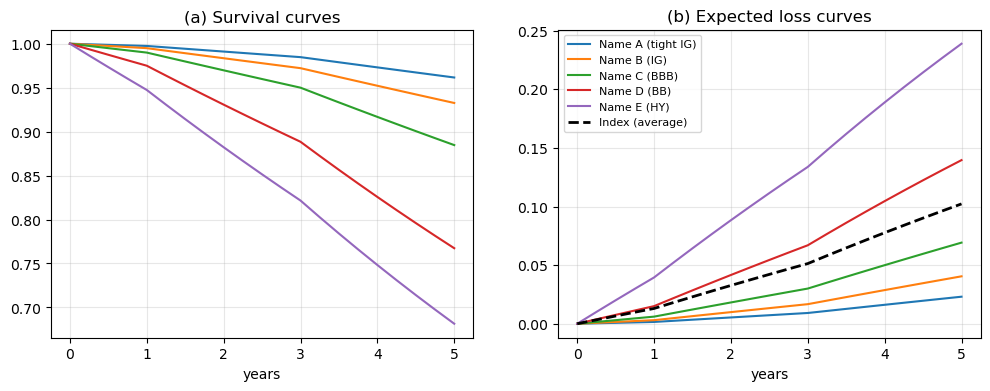

,EL(1y),EL(3y),EL(5y)
Name A (tight IG),0.0015,0.0092,0.0231
Name B (IG),0.0030,0.0167,0.0404
Name C (BBB),0.0061,0.0300,0.0692
Name D (BB),0.0150,0.0669,0.1396
Name E (HY),0.0395,0.1338,0.2389


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for j in range(N_NAMES):
    ax[0].plot(T_GRID, base["P"][j], label=NAMES[j])
    ax[1].plot(T_GRID, base["EL"][j], label=NAMES[j])
ax[1].plot(T_GRID, base["EL_I"], "k--", lw=2, label="Index (average)")
ax[0].set_title("(a) Survival curves"); ax[1].set_title("(b) Expected loss curves")
for a in ax:
    a.set_xlabel("years"); a.grid(alpha=.3)
ax[1].legend(fontsize=8)
plt.show()

display(pd.DataFrame(base["EL"][:, [n_of(T) for T in MATS]], index=NAMES,
                     columns=[f"EL({T:g}y)" for T in MATS]))

## (c) Fair spread of the bespoke index

The index loss curve is the average of the names' loss curves (Lecture 5, slide 8). With index recovery 40%, the remaining index notional is $Q_I(t) = 1-EL_I(t)/0.6$, and

$$S_{fair}(T)=\frac{\sum_n DF(t_n)\,[EL_I(t_n)-EL_I(t_{n-1})]}{\sum_n \Delta_n DF(t_n)\,\tfrac12[Q_I(t_{n-1})+Q_I(t_n)]}$$

As a cross-check we also compute the RPV01-weighted average of the CDS spreads, which follows from Lecture 3, eq. (6)–(8).

In [6]:
def legs(loss, notional, T):
    """Generic legs per unit notional.
    loss[n]    : expected fraction of notional lost by t_n (loss[0] can be > 0 for jump-to-default)
    notional[n]: expected remaining notional at t_n
    """
    n = n_of(T)
    i = np.arange(1, n + 1)
    prot  = DF[0] * loss[0] + np.sum(DF[i] * (loss[i] - loss[i - 1]))
    rpv01 = np.sum(DELTA[i] * DF[i] * (notional[i - 1] + notional[i]) / 2)
    return prot, rpv01

def index_price(model, T):
    prot, rpv01 = legs(model["EL_I"], model["Q_I"], T)
    return dict(spread=prot / rpv01, prot=prot, rpv01=rpv01)

def single_rpv01(P, T):
    n = n_of(T); i = np.arange(1, n + 1)
    return np.sum(DELTA[i] * DF[i] * (P[i - 1] + P[i]) / 2)

rows = []
for k, T in enumerate(MATS):
    ip = index_price(base, T)
    w = np.array([single_rpv01(base["P"][j], T) for j in range(N_NAMES)])
    rows.append({"Maturity": f"{T:g}y",
                 "Fair index spread (bp)": ip["spread"] * 1e4,
                 "Simple avg of CDS (bp)": SPREADS_BP[:, k].mean(),
                 "RPV01-wtd avg (bp)": (SPREADS_BP[:, k] * w).sum() / w.sum(),
                 "Index RPV01": ip["rpv01"]})
INDEX_TABLE = pd.DataFrame(rows).set_index("Maturity")
display(INDEX_TABLE)
INDEX_SPREAD = {T: index_price(base, T)["spread"] for T in MATS}   # traded = fair (given)

,Fair index spread (bp),Simple avg of CDS (bp),RPV01-wtd avg (bp),Index RPV01
Maturity,,,,
1y,129.8450,131.0000,129.6721,0.9782
3y,174.7859,179.0000,174.0161,2.7411
5y,214.9179,223.0000,213.2284,4.2402


## (d) Tranche spreads: one-factor Gaussian copula, base correlation 30%

* $p_j(t)=EL_j(t)/0.6$ and $x_j^{crit}=\Phi^{-1}(p_j(t))$ (Lecture 4, eq. 23)
* $p_j(m)=\Phi\!\left(\frac{x_j^{crit}-\sqrt\rho\,m}{\sqrt{1-\rho}}\right)$ (Lecture 4, eq. 29)
* Conditional on $M=m$ the defaults are independent. With only 5 names the conditional distribution of the number of defaults is computed **exactly** by recursion; FFT is unnecessary here. Each default adds 12 index points.
* Integrate over $M$ with Gauss–Hermite quadrature.
* Base-correlation expected tranche loss (Lecture 5, eq. 22):
$$E[L(t,K_1,K_2)]=\frac{E_{\rho(K_2)}[\min(L,K_2^-)]-E_{\rho(K_1)}[\min(L,K_1)]}{K_2^- - K_1},\quad K_2^-=\min(K_2,60)$$
* Tranche spread = protection leg / RPV01, with the legs from Lecture 5, eq. (10).

**Note on the 5-name pool:** the index loss can only be 0, 12, 24, 36, 48 or 60, so one default wipes out the whole (0,5) tranche, and the maximum loss is 60, hence the super-senior uses $K_2^-=60$ (Lecture 5, eq. 9).

**Note on the premium leg:** Lecture 5 eq. (10) writes $\frac{S}{2}\sum\Delta\,DF\,E[M]$ with $M=1-\frac{L_i+L_{i-1}}{2}$. The averaging is already inside $M$, so the code uses $S\sum\Delta\,DF\,E[M]$. This is the same convention as the CDS formula $\frac S2\sum\Delta\,DF\,(P_{i-1}+P_i)$.

In [7]:
GH_X, GH_W = hermegauss(80)
GH_W = GH_W / np.sqrt(2 * np.pi)          # weights for a standard normal M

def default_count_dist(p_cond):
    """p_cond: (n_m, N) conditional default probs -> (n_m, N+1) distribution of #defaults."""
    n_m, N = p_cond.shape
    dist = np.zeros((n_m, N + 1)); dist[:, 0] = 1.0
    for j in range(N):
        p = p_cond[:, j:j + 1]
        new = dist * (1 - p)
        new[:, 1:] += dist[:, :-1] * p
        dist = new
    return dist

def expected_min_loss(p_t, rho, K):
    """E_rho[min(L, K)] at one date, given the unconditional default probabilities p_t (N,)."""
    if K <= 0:
        return 0.0
    xcrit = norm.ppf(np.clip(p_t, 0.0, 1.0))
    pm = norm.cdf((xcrit[None, :] - np.sqrt(rho) * GH_X[:, None]) / np.sqrt(1 - rho))
    dist = default_count_dist(pm)
    payoff = np.minimum(LOSS_UNIT * np.arange(len(p_t) + 1), K)
    return GH_W @ (dist @ payoff)

def tranche_loss_curve(pdef, K1, K2, base_corr):
    K2m = min(K2, MAX_LOSS)
    r2, r1 = base_corr[K2], base_corr.get(K1, 0.0)
    return np.array([(expected_min_loss(pdef[:, n], r2, K2m) - expected_min_loss(pdef[:, n], r1, K1))
                     / (K2m - K1) for n in range(len(T_GRID))])

def price_tranche(pdef, K1, K2, T, base_corr):
    EL = tranche_loss_curve(pdef, K1, K2, base_corr)
    prot, rpv01 = legs(EL, 1 - EL, T)
    spread = prot / rpv01 if rpv01 > 1e-14 else np.nan   # nan if the tranche is already wiped out
    return dict(spread=spread, prot=prot, rpv01=rpv01, EL=EL)

def tranche_value(pdef, K1, K2, T, base_corr, S_contract):
    """Value per unit notional to the BUYER (long risk / short protection)."""
    p = price_tranche(pdef, K1, K2, T, base_corr)
    return S_contract * p["rpv01"] - p["prot"]

TR_SPREAD, TR_RPV01 = {}, {}
for T in MATS:
    for (K1, K2) in TRANCHES:
        p = price_tranche(base["pdef"], K1, K2, T, BASE_CORR_30)
        TR_SPREAD[(K1, K2, T)] = p["spread"]
        TR_RPV01[(K1, K2, T)]  = p["rpv01"]

lab = lambda K1, K2: f"({K1},{K2})"
display(pd.DataFrame({f"{T:g}y": [TR_SPREAD[(K1, K2, T)] * 1e4 for K1, K2 in TRANCHES] for T in MATS},
                     index=[lab(*k) for k in TRANCHES]).rename_axis("Tranche spread (bp)"))

# consistency check (Lecture 5, eq. 23): width-weighted tranche losses add up to the index loss
for T in MATS:
    n = n_of(T)
    tot = sum((min(K2, MAX_LOSS) - K1) * price_tranche(base["pdef"], K1, K2, T, BASE_CORR_30)["EL"][n]
              for K1, K2 in TRANCHES)
    print(f"T={T:g}y: sum of tranche losses = {tot:.6f} index pts, index EL = {100 * base['EL_I'][n]:.6f}")

,1y,3y,5y
Tranche spread (bp),,,
"(0,5)","1,013.8697","1,281.0673","1,490.5506"
"(5,15)",729.6268,946.3575,"1,125.2012"
"(15,30)",61.9313,181.9109,315.8260
"(30,100)",2.2606,13.9359,36.4290


T=1y: sum of tranche losses = 1.302037 index pts, index EL = 1.302037
T=3y: sum of tranche losses = 5.131762 index pts, index EL = 5.131762
T=5y: sum of tranche losses = 10.223056 index pts, index EL = 10.223056


## (e) RPV01 and DV01

* **RPV01**: Lecture 5, eq. (24).
* **DV01**: bump-and-run (Lecture 5, slides 30–31). Bump all 5 CDS curves by +1bp, re-bootstrap, and reprice each tranche at its **original** contract spread. Sign convention: P&L to the **long-risk (protection seller)** side, in $ per $10mm notional. Spreads widening makes this negative.
* **Leverage** = tranche DV01 / index DV01.

In [8]:
bumped = build_model(SPREADS_BP + 1.0)

rows = []
for T in MATS:
    ip_b = legs(bumped["EL_I"], bumped["Q_I"], T)
    idx_dv01 = (INDEX_SPREAD[T] * ip_b[1] - ip_b[0]) * NOTIONAL
    rows.append({"Maturity": f"{T:g}y", "Tranche": "Index", "Spread (bp)": INDEX_SPREAD[T] * 1e4,
                 "RPV01": index_price(base, T)["rpv01"], "DV01 ($)": idx_dv01, "Leverage": 1.0})
    for (K1, K2) in TRANCHES:
        dv01 = tranche_value(bumped["pdef"], K1, K2, T, BASE_CORR_30, TR_SPREAD[(K1, K2, T)]) * NOTIONAL
        rows.append({"Maturity": f"{T:g}y", "Tranche": lab(K1, K2),
                     "Spread (bp)": TR_SPREAD[(K1, K2, T)] * 1e4, "RPV01": TR_RPV01[(K1, K2, T)],
                     "DV01 ($)": dv01, "Leverage": dv01 / idx_dv01})
RISK = pd.DataFrame(rows).set_index(["Maturity", "Tranche"])
display(RISK)

Spread (bp)  RPV01     DV01 ($)  Leverage
Maturity Tranche                                            
1y       Index        129.8450 0.9782    -980.7490    1.0000
         (0,5)      1,013.8697 0.9396  -6,362.6066    6.4875
         (5,15)       729.6268 0.9532  -4,912.3239    5.0087
         (15,30)       61.9313 0.9864  -1,144.1148    1.1666
         (30,100)       2.2606 0.9888     -80.8233    0.0824
3y       Index        174.7859 2.7411  -2,766.3275    1.0000
         (0,5)      1,281.0673 2.3966 -14,109.0865    5.1003
         (5,15)       946.3575 2.5083 -11,831.2878    4.2769
         (15,30)      181.9109 2.7966  -5,547.4214    2.0053
         (30,100)      13.9359 2.8484    -819.7316    0.2963
5y       Index        214.9179 4.2402  -4,313.9444    1.0000
         (0,5)      1,490.5506 3.3477 -18,107.2844    4.1974
         (5,15)     1,125.2012 3.6136 -16,096.0388    3.7312
         (15,30)      315.8260 4.3372 -10,436.0985    2.4192
         (30,100)      36.4290 4.5493  -2,379.4091    0.5516

**What do you notice?** *(edit after running with your data)*

1. **RPV01** is smallest for the equity tranche and increases up the capital structure. Equity notional is eroded quickly by defaults (here a single default wipes it out), so its expected premium stream is short. Senior RPV01 is close to the risk-free annuity.
2. **DV01 per unit notional** is largest for the equity tranche and decreases toward the senior. The leverage numbers make this explicit: equity is many times more sensitive than the index, while the senior is a fraction of it.
3. The width-weighted DV01s of the tranches add up (approximately) to the index DV01, the same telescoping as in Lecture 5, eq. (23).
4. As maturity increases, the RPV01s grow and risk migrates up the structure: senior tranches pick up a larger share of the DV01 at long maturities, because more cumulative defaults become possible.

## (f) Jump-to-default, shortest maturity

Name $j$ defaults at $t=0^+$, so $p_j(t)=1$ for all $t$. The immediate tranche loss is paid at $t=0$ (included in the protection leg through `loss[0]`). The remaining names are priced as before, and the contract spread is unchanged. JTD = value after − value before, where value before = 0 because the tranche is at par. Sign convention: long risk, $ per $10mm notional.

In [9]:
T0 = MATS.min()
jtd = {}
for j in range(N_NAMES):
    pd_j = base["pdef"].copy(); pd_j[j, :] = 1.0
    jtd[NAMES[j]] = {lab(K1, K2): tranche_value(pd_j, K1, K2, T0, BASE_CORR_30, TR_SPREAD[(K1, K2, T0)]) * NOTIONAL
                     for (K1, K2) in TRANCHES}
    # index: name j defaults -> EL_I jumps by 0.6/5 at t=0 (index recovery 40%)
    EL_I_j = (base["EL_I"] * N_NAMES - (1 - RECOV[j]) * (1 - base["P"][j]) + (1 - R_INDEX)) / N_NAMES
    EL_I_j[0] = (1 - R_INDEX) / N_NAMES
    pr, rp = legs(EL_I_j, 1 - EL_I_j / (1 - R_INDEX), T0)
    jtd[NAMES[j]]["Index"] = (INDEX_SPREAD[T0] * rp - pr) * NOTIONAL
JTD = pd.DataFrame(jtd).T
JTD.insert(0, f"CDS {T0:g}y (bp)", SPREADS_BP[:, 0])
display(JTD.style.format("{:,.0f}"))

,CDS 1y (bp),"(0,5)","(5,15)","(15,30)","(30,100)",Index
Name A (tight IG),15,"-10,000,000","-7,075,521","-538,628","-18,486","-1,222,686"
Name B (IG),30,"-10,000,000","-7,070,359","-526,040","-16,563","-1,219,698"
Name C (BBB),60,"-10,000,000","-7,059,325","-500,021","-13,438","-1,213,745"
Name D (BB),150,"-10,000,000","-7,022,987","-418,833","-7,263","-1,196,063"
Name E (HY),400,"-10,000,000","-6,905,342","-183,795","-3,109","-1,147,808"


**How does JTD change with the underlying's spread?** *(edit after running)*

* **(0,5) equity:** any single default exhausts the tranche, so JTD ≈ −100% of notional (−$10mm) **regardless of which name defaults**. The default is already "priced" only through the premium the buyer was receiving. This is a feature of a lumpy 5-name pool. With 125 names the equity JTD would be about −0.48/3 of notional per default and would vary with spread.
* **(5,15), (15,30), (30,100):** the immediate loss is the same for every name, but the value of what remains differs. When a **tight** name defaults, the 4 survivors are the wider (riskier) names, so the remaining tranche is worth less and JTD is **more negative**. When the **widest** name defaults, its default was largely expected and the remaining pool is safer, so JTD is smaller in magnitude. JTD magnitude therefore **decreases as the spread of the defaulting name increases**.
* The model does not update the market factor $M$ after a default (no contagion). In reality a default would widen the survivors, so the JTD on the senior tranches is understated.

## (g) Our view: correlation should be 50%, not 30%

Raising $\rho$ moves probability mass to the tails of the loss distribution (Lecture 4, slide 21; Lecture 5, slide 27):

* **Equity** loses less on average → it is worth **more to the long-risk buyer**.
* **Senior** loses more → protection on it is worth **more**.
* **Mezzanine** is in general not monotone in $\rho$ (Lecture 5, slide 27). In this lumpy 5-name pool, however, the first default (12 pts) already hits (5,15), so it behaves like a second equity tranche. Check the sign in the table below.

**Trade:** sell protection on (0,5) equity and buy protection on the senior tranche(s), (15,30) and/or (30,100). This is the Magnetar trade (Lecture 5, slides 34–35): a bet that correlation is too low. The table reprices every tranche at $\rho=50\%$ while keeping the 30% contract spreads.

In [10]:
BASE_CORR_50 = {k: 0.50 for k in BASE_CORR_30}
rows = []
for T in MATS:
    for (K1, K2) in TRANCHES:
        S = TR_SPREAD[(K1, K2, T)]
        v50 = tranche_value(base["pdef"], K1, K2, T, BASE_CORR_50, S) * NOTIONAL
        corr01 = tranche_value(base["pdef"], K1, K2, T, {k: 0.31 for k in BASE_CORR_30}, S) * NOTIONAL
        rows.append({"Maturity": f"{T:g}y", "Tranche": lab(K1, K2),
                     "Spread @30% (bp)": S * 1e4,
                     "Spread @50% (bp)": price_tranche(base["pdef"], K1, K2, T, BASE_CORR_50)["spread"] * 1e4,
                     "Long-risk P&L if ρ→50% ($)": v50,
                     "corr01 long risk ($/1%)": corr01})
CORR = pd.DataFrame(rows).set_index(["Maturity", "Tranche"])
display(CORR)

Spread @30% (bp)  Spread @50% (bp)  \
Maturity Tranche                                        
1y       (0,5)           1,013.8697          929.5611   
         (5,15)            729.6268          688.9425   
         (15,30)            61.9313          101.3130   
         (30,100)            2.2606            8.1523   
3y       (0,5)           1,281.0673        1,138.8584   
         (5,15)            946.3575          871.5320   
         (15,30)           181.9109          226.3319   
         (30,100)           13.9359           29.7409   
5y       (0,5)           1,490.5506        1,311.7607   
         (5,15)          1,125.2012        1,025.3937   
         (15,30)           315.8260          348.9198   
         (30,100)           36.4290           60.3835   

                   Long-risk P&L if ρ→50% ($)  corr01 long risk ($/1%)  
Maturity Tranche                                                        
1y       (0,5)                    79,524.8967               3,464.3445  
         (5,15)                   38,852.7241               1,608.9467  
         (15,30)                 -38,771.0200              -1,790.8316  
         (30,100)                 -5,824.4564                -177.7320  
3y       (0,5)                   346,764.7902              16,942.2553  
         (5,15)                  189,381.7939               8,886.1661  
         (15,30)                -123,391.9897              -6,645.8804  
         (30,100)                -44,937.6921              -1,808.8166  
5y       (0,5)                   618,916.7627              31,224.7264  
         (5,15)                  367,393.1811              18,068.0276  
         (15,30)                -142,108.9354              -8,224.1377  
         (30,100)               -108,498.1869              -4,916.1088

## (h) Making the trade dollar-neutral

**DV01-neutral** (spread-neutral): sell protection on $N_{eq}$ of equity and buy protection on $N_{sen}$ of senior with

$$N_{sen}=N_{eq}\,\frac{DV01_{eq}}{DV01_{sen}}$$

This leaves (to first order) a pure correlation exposure. For comparison we also compute the **carry-neutral** ratio $N_{sen}=N_{eq}\,S_{eq}/S_{sen}$, which is Magnetar-style zero carry. Both packages cost nothing upfront because all tranches start at par.

In [11]:
def neutral_package(T, senior=(30, 100), N_eq=NOTIONAL):
    eq = (0, 5)
    dv_eq  = RISK.loc[(f"{T:g}y", lab(*eq)), "DV01 ($)"] / NOTIONAL
    dv_sen = RISK.loc[(f"{T:g}y", lab(*senior)), "DV01 ($)"] / NOTIONAL
    S_eq, S_sen = TR_SPREAD[(*eq, T)], TR_SPREAD[(*senior, T)]
    out = {}
    for kind, N_sen in [("DV01-neutral", N_eq * dv_eq / dv_sen), ("Carry-neutral", N_eq * S_eq / S_sen)]:
        # long risk equity (+N_eq), short risk senior (-N_sen)
        val = lambda pdef, bc: (N_eq * tranche_value(pdef, *eq, T, bc, S_eq)
                                - N_sen * tranche_value(pdef, *senior, T, bc, S_sen))
        jtds = []
        for j in range(N_NAMES):
            pd_j = base["pdef"].copy(); pd_j[j, :] = 1.0
            jtds.append(val(pd_j, BASE_CORR_30))
        out[kind] = {"Senior notional ($)": N_sen,
                     "Net DV01 ($)": N_eq * dv_eq - N_sen * dv_sen,
                     "Net carry ($/yr)": N_eq * S_eq - N_sen * S_sen,
                     "P&L if ρ→50% ($)": val(base["pdef"], BASE_CORR_50),
                     "Worst JTD ($)": min(jtds), "Best JTD ($)": max(jtds)}
    return pd.DataFrame(out)

for senior in [(30, 100), (15, 30)]:
    for T in MATS:
        print(f"\n=== {T:g}y: long risk $10mm (0,5) vs short risk {lab(*senior)} ===")
        display(neutral_package(T, senior=senior).style.format("{:,.0f}"))


=== 1y: long risk $10mm (0,5) vs short risk (30,100) ===


,DV01-neutral,Carry-neutral
Senior notional ($),"787,224,061","4,484,895,439"
Net DV01 ($),0,"29,886"
Net carry ($/yr),"835,907",0
P&L if ρ→50% ($),"538,040","2,691,733"
Worst JTD ($),"-9,755,237","-8,605,562"
Best JTD ($),"-8,544,704","-1,709,029"



=== 3y: long risk $10mm (0,5) vs short risk (30,100) ===


,DV01-neutral,Carry-neutral
Senior notional ($),"172,118,363","919,254,994"
Net DV01 ($),0,"61,245"
Net carry ($/yr),"1,041,204",0
P&L if ρ→50% ($),"1,120,225","4,477,685"
Worst JTD ($),"-9,582,706","-7,771,306"
Best JTD ($),"-7,386,934","3,955,944"



=== 5y: long risk $10mm (0,5) vs short risk (30,100) ===


...

,DV01-neutral,Carry-neutral
Senior notional ($),"55,611,609","163,708,679"
Net DV01 ($),0,"12,368"
Net carry ($/yr),"669,460",0
P&L if ρ→50% ($),"295,137","714,240"
Worst JTD ($),"-8,977,889","-6,991,124"
Best JTD ($),"-7,004,601","-1,182,185"



=== 3y: long risk $10mm (0,5) vs short risk (15,30) ===


,DV01-neutral,Carry-neutral
Senior notional ($),"25,433,594","70,422,792"
Net DV01 ($),0,"24,957"
Net carry ($/yr),"818,403",0
P&L if ρ→50% ($),"660,595","1,215,726"
Worst JTD ($),"-8,526,327","-5,919,564"
Best JTD ($),"-5,857,107","1,471,210"



=== 5y: long risk $10mm (0,5) vs short risk (15,30) ===


,DV01-neutral,Carry-neutral
Senior notional ($),"17,350,626","47,195,305"
Net DV01 ($),0,"31,146"
Net carry ($/yr),"942,573",0
P&L if ρ→50% ($),"865,485","1,289,604"
Worst JTD ($),"-8,515,704","-5,962,579"
Best JTD ($),"-5,656,322","1,815,205"


**Discussion** *(edit after running)*

* Yes, the trade can be made **DV01-neutral** by sizing the senior leg as above. Because the senior DV01 per unit notional is small, the senior notional is many times the equity notional. With (30,100) as the hedge, especially at short maturities, the notional becomes impractically large, so hedging with (15,30) is more realistic. Both legs are at par, so the package is also zero cost at inception. The leftover exposure is mainly to correlation: the "P&L if ρ→50%" row is the payoff of our view.
* The DV01-neutral package is generally **not carry-neutral**, and vice versa. You have to choose which "neutrality" you want. Adding an index leg as a third instrument lets you hit two targets at once (e.g. DV01 = 0 and carry = 0).
* It is **not JTD-neutral**: an early default wipes out the equity leg, and the senior protection gains little on a single default, so the package has large negative JTD (see worst/best JTD rows). It is also only locally DV01-neutral (gamma), so it must be rebalanced as spreads move. This idiosyncratic default risk is exactly what the Magnetar-style trade leaves open.